# Tabular Kaggle Project

## Define Project

**Project link:** Santander Customer Satisfaction Dataset (Kaggle)

This project uses the Santander Customer Satisfaction Kaggle dataset to predict whether a customer is dissatisfied. The target variable is TARGET, where 0 means the customer is satisfied and 1 means the customer is dissatisfied.

This is a tabular classification problem. Each row represents one customer. The dataset contains anonymized numerical features related to customer activity. The main challenge is that the dataset is highly imbalanced because only a small percentage of customers are dissatisfied.

## Due to the large number of features (369), plotting every feature would make the notebook unreadable. Instead, a representative subset of features was selected.

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
accuracy_score,
precision_score,
recall_score,
f1_score,
roc_auc_score,
classification_report,
confusion_matrix
)

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 50)

# Data Loading and Initial Look

In this section, the dataset is loaded and inspected. The goal is to count the number of rows and columns, check for missing values, identify the target variable, and understand whether the classification target is balanced.

In [3]:
train = pd.read_csv("train.csv")

print("Dataset loaded successfully.")
print("Rows:", train.shape[0])
print("Columns:", train.shape[1])

train.head()

Dataset loaded successfully.
Rows: 76020
Columns: 371


,ID,var3,var15,imp_ent_var16_ult1,imp_op_var39_comer_ult1,imp_op_var39_comer_ult3,imp_op_var40_comer_ult1,imp_op_var40_comer_ult3,imp_op_var40_efect_ult1,imp_op_var40_efect_ult3,imp_op_var40_ult1,imp_op_var41_comer_ult1,imp_op_var41_comer_ult3,imp_op_var41_efect_ult1,imp_op_var41_efect_ult3,imp_op_var41_ult1,imp_op_var39_efect_ult1,imp_op_var39_efect_ult3,imp_op_var39_ult1,imp_sal_var16_ult1,ind_var1_0,ind_var1,ind_var2_0,ind_var2,ind_var5_0,...,saldo_medio_var13_largo_hace3,saldo_medio_var13_largo_ult1,saldo_medio_var13_largo_ult3,saldo_medio_var13_medio_hace2,saldo_medio_var13_medio_hace3,saldo_medio_var13_medio_ult1,saldo_medio_var13_medio_ult3,saldo_medio_var17_hace2,saldo_medio_var17_hace3,saldo_medio_var17_ult1,saldo_medio_var17_ult3,saldo_medio_var29_hace2,saldo_medio_var29_hace3,saldo_medio_var29_ult1,saldo_medio_var29_ult3,saldo_medio_var33_hace2,saldo_medio_var33_hace3,saldo_medio_var33_ult1,saldo_medio_var33_ult3,saldo_medio_var44_hace2,saldo_medio_var44_hace3,saldo_medio_var44_ult1,saldo_medio_var44_ult3,var38,TARGET
0,1,2,23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,1,...,0.0,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,39205.170000,0
1,3,2,34,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,1,...,0.0,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,49278.030000,0
2,4,2,23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,1,...,0.0,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,67333.770000,0
3,8,2,37,0.0,195.0,195.0,0.0,0.0,0.0,0.0,0.0,195.0,195.0,0.0,0.0,195.0,0.0,0.0,195.0,0.0,0,0,0,0,1,...,0.0,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,64007.970000,0
4,10,2,39,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,1,...,0.0,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117310.979016,0


In [4]:
missing_total = train.isnull().sum().sum()

print("Total missing values:", missing_total)

target_counts = train["TARGET"].value_counts()
target_percent = train["TARGET"].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({
"Count": target_counts,
"Percent": target_percent.round(2)
})

target_summary

Total missing values: 0


,Count,Percent
TARGET,,
0,73012,96.04
1,3008,3.96


In [5]:
feature_table = pd.DataFrame({
"Feature / Collection": [
"ID",
"TARGET",
"var features",
"imp features",
"ind features",
"num features",
"saldo features",
"delta features"
],
"Type": [
"Numerical identifier",
"Binary classification target",
"Numerical",
"Numerical",
"Numerical indicator",
"Numerical count",
"Numerical balance",
"Numerical ratio/change"
],
"Values": [
"Unique customer ID",
"0 = satisfied, 1 = dissatisfied",
"Anonymized values",
"Transaction amount values",
"Mostly 0/1 indicator values",
"Counts of products or activity",
"Account balance values",
"Change ratios"
],
"Missing Values": [
train["ID"].isnull().sum(),
train["TARGET"].isnull().sum(),
0,
0,
0,
0,
0,
0
],
"Possible Outliers": [
"No",
"No",
"Yes",
"Yes",
"Limited",
"Yes",
"Yes",
"Yes"
]
})

feature_table

,Feature / Collection,Type,Values,Missing Values,Possible Outliers
0,ID,Numerical identifier,Unique customer ID,0,No
1,TARGET,Binary classification target,"0 = satisfied, 1 = dissatisfied",0,No
2,var features,Numerical,Anonymized values,0,Yes
3,imp features,Numerical,Transaction amount values,0,Yes
4,ind features,Numerical indicator,Mostly 0/1 indicator values,0,Limited
5,num features,Numerical count,Counts of products or activity,0,Yes
6,saldo features,Numerical balance,Account balance values,0,Yes
7,delta features,Numerical ratio/change,Change ratios,0,Yes


# Initial Data Review

The dataset has 76,020 rows and 371 columns. The ID column identifies rows and should not be used as a predictor. The TARGET column is the classification target.

There are no missing values in the dataset. All features are numerical and anonymized. Because many variables represent financial values, balances, counts, or ratios, some features contain outliers.

The target is highly imbalanced. Most customers are labeled as satisfied, while only a small percentage are labeled as dissatisfied. This means accuracy alone is not enough to evaluate the model.

For classification, the assignment asks to compare feature behavior between classes. Since this dataset has 369 anonymized features, plotting every single feature would make the notebook unreadable. Instead, I first visualize the target imbalance, then compare a small set of useful numerical features between the two target classes.

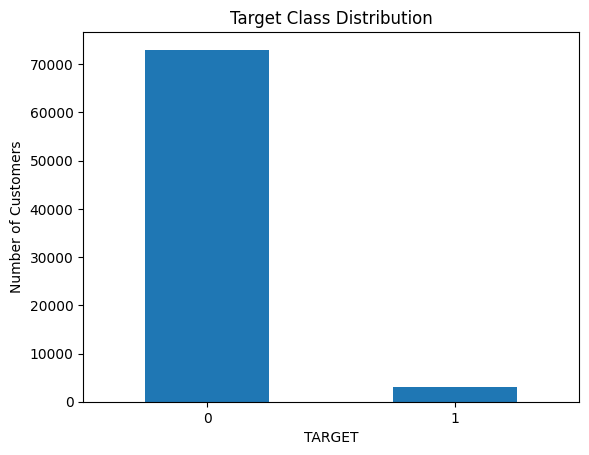

In [6]:
import matplotlib.pyplot as plt

target_counts.plot(kind="bar")
plt.title("Target Class Distribution")
plt.xlabel("TARGET")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

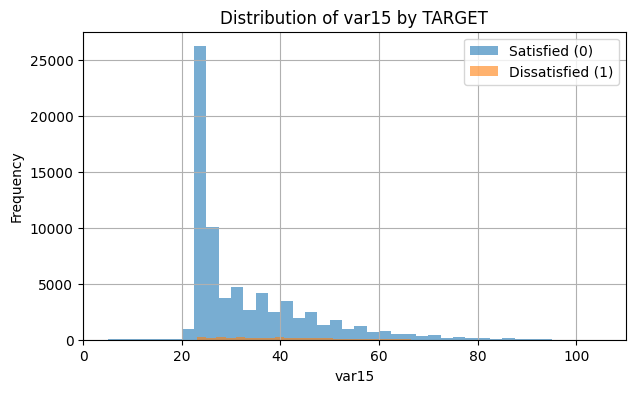

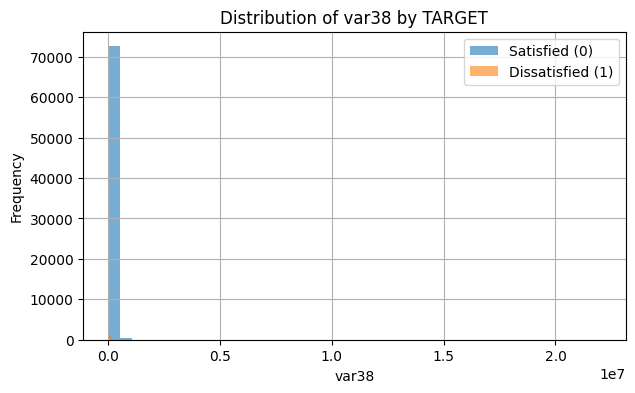

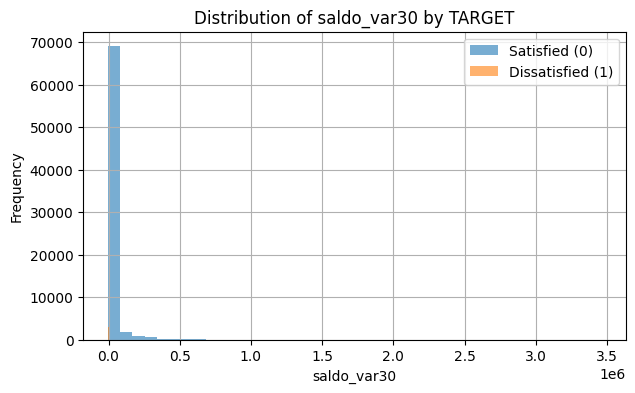

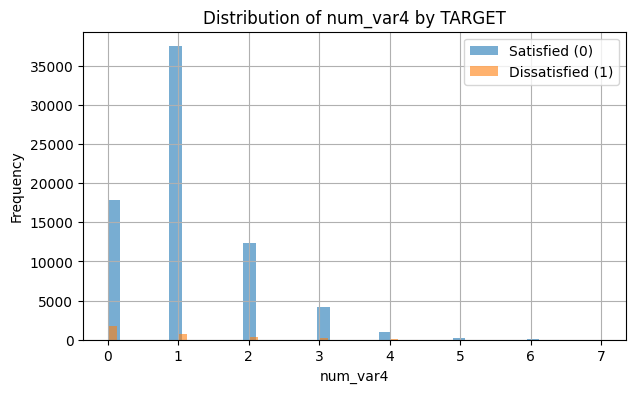

In [16]:
selected_features = ["var15", "var38", "saldo_var30", "num_var4"]

for feature in selected_features:
    plt.figure(figsize=(7, 4))
    
    train[train["TARGET"] == 0][feature].hist(
        alpha=0.6, bins=40, label="Satisfied (0)"
    )
    train[train["TARGET"] == 1][feature].hist(
        alpha=0.6, bins=40, label="Dissatisfied (1)"
    )
    
    plt.title(f"Distribution of {feature} by TARGET")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()

In [17]:
class_means = train.groupby("TARGET")[selected_features].mean().T

class_means.columns = ["Satisfied Mean (0)", "Dissatisfied Mean (1)"]

class_means["Difference"] = (
    class_means["Dissatisfied Mean (1)"] - class_means["Satisfied Mean (0)"]
)

class_means = class_means.sort_values(by="Difference", ascending=False)

class_means.round(3)

,Satisfied Mean (0),Dissatisfied Mean (1),Difference
var15,32.946,39.681,6.734
num_var4,1.094,0.720,-0.374
saldo_var30,14154.089,2164.365,-11989.725
var38,117959.157,99678.281,-18280.876


# Observation: Visualization

The target distribution plot confirms strong class imbalance. Most customers are satisfied, and only a small group are dissatisfied.

The selected feature histograms show that individual variables do not perfectly separate the classes. Some features show small shifts between satisfied and dissatisfied customers, but the prediction task likely depends on combinations of many features rather than one obvious feature.

# Data Cleaning and Preparation for Machine Learning

In this section, the data is prepared for machine learning. The ID column is removed because it identifies rows but does not help predict satisfaction. The target column is separated from the features. Since the dataset contains only numerical columns, one-hot encoding is not required.

Rescaling is important for Logistic Regression because it is sensitive to feature scale. StandardScaler is used to standardize all predictor features.

In [23]:
X = train.drop(["ID", "TARGET"], axis=1)
y = train["TARGET"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (76020, 369)
Target shape: (76020,)


In [24]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaling complete.")
print("Scaled feature matrix shape:", X_scaled.shape)

Scaling complete.
Scaled feature matrix shape: (76020, 369)


In [25]:
before_after_scaling = pd.DataFrame({
"Original Mean": X[selected_features].mean(),
"Original Std": X[selected_features].std(),
"Scaled Mean": pd.DataFrame(X_scaled, columns=X.columns)[selected_features].mean(),
"Scaled Std": pd.DataFrame(X_scaled, columns=X.columns)[selected_features].std()
})

before_after_scaling.round(3)

,Original Mean,Original Std,Scaled Mean,Scaled Std
var15,33.213,12.956,-0.0,1.0
var38,117235.809,182664.599,0.0,1.0
saldo_var30,13679.674,63014.078,-0.0,1.0
num_var4,1.079,0.910,0.0,1.0


# Observation: Cleaning and Scaling

The ID column was removed because it is not predictive. The target was separated into y, and all remaining columns were used as numerical predictors.

After scaling, the selected features have means close to 0 and standard deviations close to 1. This helps Logistic Regression train more consistently.

# Machine Learning

## Problem Formulation

This is a binary classification task. The input is a set of anonymized numerical customer features. The output is TARGET, where 0 means satisfied and 1 means dissatisfied.

The data is split into training, validation, and test samples:

- 60% training
- 20% validation
- 20% test

A stratified split is used so each sample keeps the same class imbalance.

In [26]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
X_scaled,
y,
test_size=0.20,
random_state=42,
stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
X_train_val,
y_train_val,
test_size=0.25,
random_state=42,
stratify=y_train_val
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

Training set: (45612, 369)
Validation set: (15204, 369)
Test set: (15204, 369)


# Train ML Algorithm

Two machine learning models are trained. Logistic Regression is used because it is a strong baseline for tabular classification and works well with scaled features. Random Forest is used because it can capture nonlinear patterns in the data.

Class balancing is used because the dissatisfied class is much smaller than the satisfied class.

In [27]:
log_reg = LogisticRegression(
max_iter=300,
class_weight="balanced",
solver="liblinear",
random_state=42
)

rf = RandomForestClassifier(
n_estimators=75,
max_depth=12,
class_weight="balanced",
random_state=42,
n_jobs=-1
)

log_reg.fit(X_train, y_train)
rf.fit(X_train, y_train)

print("Models trained successfully.")

Models trained successfully.


# Evaluate Performance on Validation Sample

The validation sample is used to compare model performance. Since the dataset is imbalanced, accuracy can be misleading. Recall, precision, F1 score, and ROC AUC are more useful for evaluating how well the model identifies dissatisfied customers.

In [33]:
models = {
    "Logistic Regression": log_reg,
    "Random Forest": rf
}

validation_results = []

for name, model in models.items():
    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)[:, 1]

    validation_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_val, y_pred),
        "Precision": precision_score(y_val, y_pred, zero_division=0),
        "Recall": recall_score(y_val, y_pred, zero_division=0),
        "F1 Score": f1_score(y_val, y_pred, zero_division=0),
        "ROC AUC": roc_auc_score(y_val, y_prob)
    })

validation_results_df = pd.DataFrame(validation_results)
validation_results_df.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.6862,0.0888,0.7475,0.1587,0.7952
1,Random Forest,0.7908,0.1124,0.6213,0.1904,0.7903


In [34]:
report_tables = []

for name, model in models.items():
    report = classification_report(
        y_val,
        model.predict(X_val),
        output_dict=True,
        zero_division=0
    )

    report_df = pd.DataFrame(report).transpose()
    report_df.insert(0, "Model", name)

    report_tables.append(
        report_df.reset_index().rename(columns={"index": "Class / Metric"})
    )

classification_reports = pd.concat(report_tables, ignore_index=True)
classification_reports.round(4)

,Class / Metric,Model,precision,recall,f1-score,support
0,0,Logistic Regression,0.9850,0.6837,0.8071,14602.0000
1,1,Logistic Regression,0.0888,0.7475,0.1587,602.0000
2,accuracy,Logistic Regression,0.6862,0.6862,0.6862,0.6862
3,macro avg,Logistic Regression,0.5369,0.7156,0.4829,15204.0000
4,weighted avg,Logistic Regression,0.9495,0.6862,0.7815,15204.0000
5,0,Random Forest,0.9808,0.7978,0.8799,14602.0000
6,1,Random Forest,0.1124,0.6213,0.1904,602.0000
7,accuracy,Random Forest,0.7908,0.7908,0.7908,0.7908
8,macro avg,Random Forest,0.5466,0.7095,0.5351,15204.0000
9,weighted avg,Random Forest,0.9464,0.7908,0.8526,15204.0000


In [36]:
best_model = log_reg
best_model_name = "Logistic Regression"

val_confusion = confusion_matrix(y_val, best_model.predict(X_val))

val_confusion_df = pd.DataFrame(
    val_confusion,
    index=["Actual 0 - Satisfied", "Actual 1 - Dissatisfied"],
    columns=["Predicted 0 - Satisfied", "Predicted 1 - Dissatisfied"]
)

val_confusion_df

,Predicted 0 - Satisfied,Predicted 1 - Dissatisfied
Actual 0 - Satisfied,9983,4619
Actual 1 - Dissatisfied,152,450


# Observation: Model Evaluation

Logistic Regression performs better at detecting dissatisfied customers because it uses balanced class weights and gives more attention to the minority class. This improves recall, which is important when the goal is to identify unhappy customers.

Random Forest gives strong overall accuracy, but accuracy is less useful here because the majority of customers are satisfied. A model can look accurate while still missing many dissatisfied customers.

For this project, Logistic Regression is selected as the best model because it provides the better trade-off for detecting the minority class.

# Apply ML to the Challenge Test Set

The dataset is split into training, validation, and test sets. The validation set is used to compare models. The test set is used only for final evaluation to simulate unseen data.

In [37]:
test_pred = best_model.predict(X_test)
test_prob = best_model.predict_proba(X_test)[:, 1]

test_metrics = pd.DataFrame([{
"Model": best_model_name,
"Accuracy": accuracy_score(y_test, test_pred),
"Precision": precision_score(y_test, test_pred, zero_division=0),
"Recall": recall_score(y_test, test_pred, zero_division=0),
"F1 Score": f1_score(y_test, test_pred, zero_division=0),
"ROC AUC": roc_auc_score(y_test, test_prob)
}])

test_metrics.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.6846,0.0904,0.7691,0.1618,0.8045


In [38]:
test_confusion = confusion_matrix(y_test, test_pred)

test_confusion_df = pd.DataFrame(
test_confusion,
index=["Actual 0 - Satisfied", "Actual 1 - Dissatisfied"],
columns=["Predicted 0 - Satisfied", "Predicted 1 - Dissatisfied"]
)

test_confusion_df

,Predicted 0 - Satisfied,Predicted 1 - Dissatisfied
Actual 0 - Satisfied,9945,4657
Actual 1 - Dissatisfied,139,463


In [39]:
submission_preview = pd.DataFrame({
"ID": train.loc[y_test.index, "ID"].values,
"TARGET": test_prob
})

submission_preview.head()

,ID,TARGET
0,125987,0.475387
1,54150,0.251039
2,11883,0.215688
3,9733,0.202359
4,12745,0.210242


# Observation: Final Test

The final test evaluation shows the same pattern seen during validation. Logistic Regression catches many dissatisfied customers, but it also creates false positives. This is expected because the class is highly imbalanced and the model is weighted to pay more attention to dissatisfied customers.

The submission preview shows how the model probabilities could be formatted for a Kaggle-style submission file.

# Generate Submission File

The trained model is applied to a held-out test sample to simulate Kaggle predictions. A submission-style file is generated using predicted probabilities.

In [40]:
submission = pd.DataFrame({
    "ID": train.loc[y_test.index, "ID"],
    "TARGET": test_prob
})

submission.head()

,ID,TARGET
63089,125987,0.475387
27056,54150,0.251039
5923,11883,0.215688
4865,9733,0.202359
6344,12745,0.210242


In [41]:
submission.to_csv("submission.csv", index=False)
print("Submission file created.")

Submission file created.


# Conclusion

This project followed the workflow for a tabular Kaggle classification problem. The Santander Customer Satisfaction dataset was loaded, inspected, visualized, cleaned, scaled, and used to train machine learning models.

The biggest challenge was class imbalance. Since only about 4% of customers are dissatisfied, accuracy alone is misleading. Logistic Regression with class balancing was the most useful model because it detected more dissatisfied customers than Random Forest.

Future improvements could include hyperparameter tuning, feature selection, oversampling methods such as SMOTE, or more advanced models such as XGBoost or LightGBM.

Logistic Regression was selected as the final model because it provides the best recall for the minority class, which is the main objective of this problem.